In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings, os
 
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
 
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)
os.makedirs("data", exist_ok=True)

### LOAD & FEATURE SELECTION

In [2]:
df = pd.read_parquet("D:/project/Global AI Adoption & Workforce Impact/Notebook/data/cleaned.parquet")
df.shape

(150000, 52)

In [3]:
CATEGORICAL = [
    "region", "industry", "company_size",
    "ai_primary_tool", "ai_use_case", "data_privacy_level",
]
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df[CATEGORICAL] = enc.fit_transform(df[CATEGORICAL])

In [4]:
# Behaviour/investment signals — avoid target-family leakage
CLUSTER_FEATURES = [
    "ai_maturity_score",     "ai_failure_rate",       "num_ai_tools_used",
    "ai_projects_active",    "task_automation_rate",  "ai_training_hours",
    "ai_budget_percentage",  "years_using_ai",        "time_saved_per_week",
    "regulatory_compliance_score", "ai_risk_management_score",
    "log_annual_revenue_usd_millions", "log_num_employees",
]
 
X_cl = (
    df[CLUSTER_FEATURES]
    .apply(lambda c: c.cat.codes if hasattr(c, "cat") else c)
    .astype(float)
    .dropna()
)

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cl)
print(f"  Clustering on {X_cl.shape[0]:,} rows × {X_cl.shape[1]} features")

  Clustering on 150,000 rows × 13 features


### OPTIMAL K SEARCH

In [6]:
print("\nSearching optimal k (2–8)...")
inertias, sil_scores, db_scores = [], [], []
ks = range(2, 9)
 
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=10000, random_state=42))
    db_scores.append(davies_bouldin_score(X_scaled[:10000], labels[:10000]))
    print(f"  k={k}  inertia={km.inertia_:.0f}  sil={sil_scores[-1]:.4f}  db={db_scores[-1]:.4f}")


Searching optimal k (2–8)...
  k=2  inertia=1437539  sil=0.2197  db=1.6216
  k=3  inertia=1294396  sil=0.1489  db=2.0146
  k=4  inertia=1202868  sil=0.1338  db=2.0260
  k=5  inertia=1142698  sil=0.1153  db=2.0875
  k=6  inertia=1101965  sil=0.1048  db=2.1449
  k=7  inertia=1069965  sil=0.0960  db=2.2998
  k=8  inertia=1039142  sil=0.0950  db=2.2822


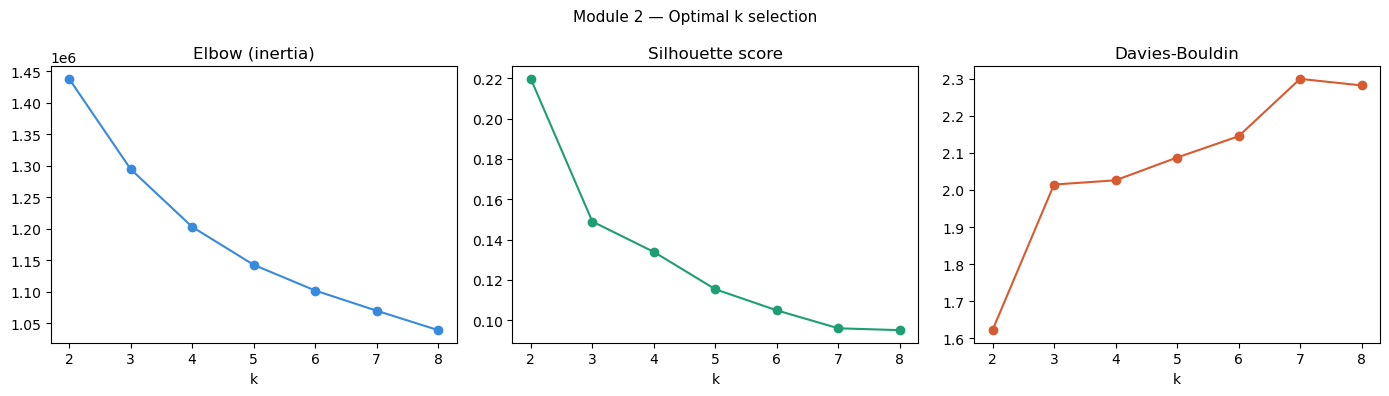

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(list(ks), inertias,   "o-", color="#378ADD"); axes[0].set_title("Elbow (inertia)");    axes[0].set_xlabel("k")
axes[1].plot(list(ks), sil_scores, "o-", color="#1D9E75"); axes[1].set_title("Silhouette score");   axes[1].set_xlabel("k")
axes[2].plot(list(ks), db_scores,  "o-", color="#D85A30"); axes[2].set_title("Davies-Bouldin");     axes[2].set_xlabel("k")
plt.suptitle("Module 2 — Optimal k selection", fontsize=11)
plt.tight_layout()
plt.show()

### FIT FINAL MODEL (k=4)

In [8]:
K = 4
print(f"\nFitting KMeans k={K} (n_init=20)...")
km = KMeans(n_clusters=K, random_state=42, n_init=20)
labels = km.fit_predict(X_scaled)
 
sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
db  = davies_bouldin_score(X_scaled[:10000], labels[:10000])
print(f"  Silhouette: {sil:.4f}   Davies-Bouldin: {db:.4f}")
 
df2 = df.loc[X_cl.index].copy()
df2["cluster"] = labels


Fitting KMeans k=4 (n_init=20)...
  Silhouette: 0.1338   Davies-Bouldin: 2.0260


### PROFILE & NAME CLUSTERS

In [9]:
PROFILE_COLS = [
    "ai_maturity_score", "ai_failure_rate", "ai_budget_percentage",
    "years_using_ai", "num_ai_tools_used", "task_automation_rate",
    "revenue_growth_percent", "productivity_change_percent",
    "cost_reduction_percent", "ai_training_hours",
]
 
profile = df2.groupby("cluster")[PROFILE_COLS].mean().round(3)

In [10]:
# Name by maturity/failure signature
cluster_names = {}
for c in range(K):
    mat  = profile.loc[c, "ai_maturity_score"]
    fail = profile.loc[c, "ai_failure_rate"]
    if mat > 0.45:
        cluster_names[c] = "AI leaders"
    elif mat > 0.35 and fail < 25:
        cluster_names[c] = "Steady adopters"
    elif mat > 0.28 and fail > 27:
        cluster_names[c] = "Struggling experimenters"
    else:
        cluster_names[c] = "Early-stage / laggards"
 
print("\nCluster summary:")
size_dist = df2["cluster"].value_counts().sort_index()
for c in range(K):
    n = size_dist[c]
    print(f"  C{c} {cluster_names[c]:<28}  n={n:>7,} ({n/len(df2)*100:.1f}%)  "
          f"maturity={profile.loc[c,'ai_maturity_score']:.3f}  "
          f"failure={profile.loc[c,'ai_failure_rate']:.1f}%  "
          f"revenue_growth={profile.loc[c,'revenue_growth_percent']:.2f}%")


Cluster summary:
  C0 Struggling experimenters      n= 35,767 (23.8%)  maturity=0.334  failure=27.4%  revenue_growth=4.08%
  C1 AI leaders                    n= 28,009 (18.7%)  maturity=0.527  failure=17.7%  revenue_growth=7.72%
  C2 Steady adopters               n= 43,195 (28.8%)  maturity=0.382  failure=22.8%  revenue_growth=5.50%
  C3 Early-stage / laggards        n= 43,029 (28.7%)  maturity=0.197  failure=32.6%  revenue_growth=2.12%


### PCA VISUALISATION

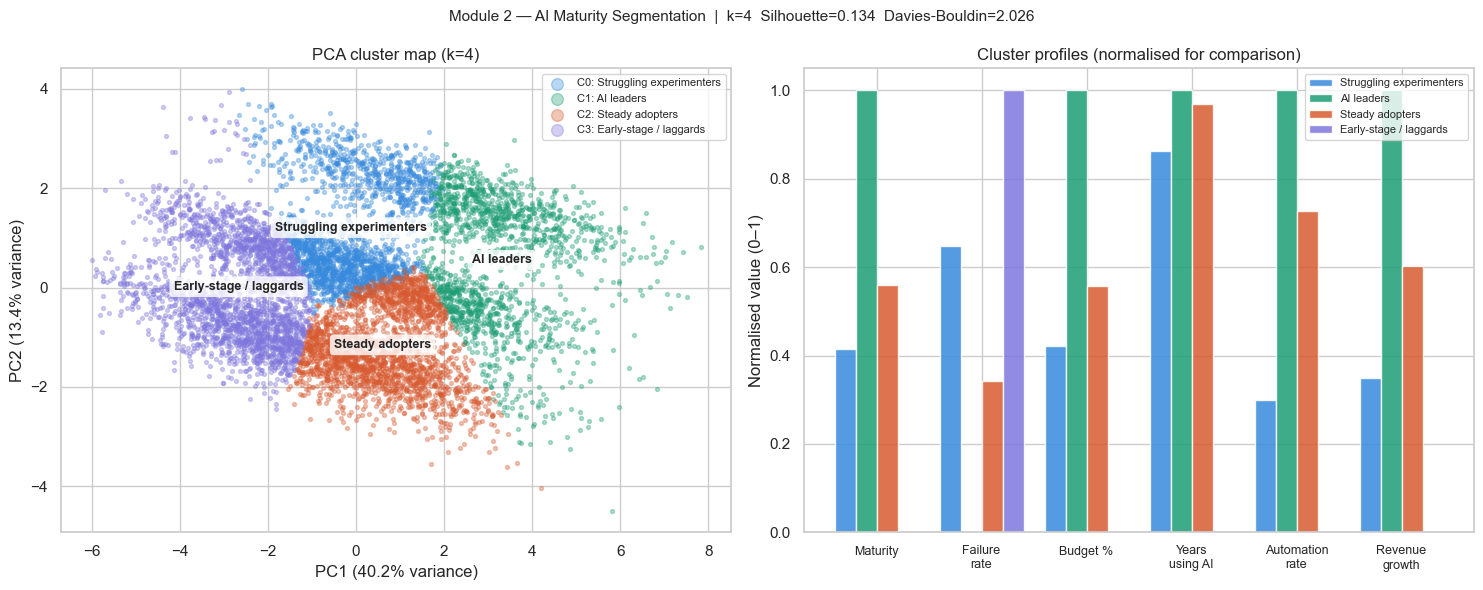

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_
 
COLORS = ["#378ADD", "#1D9E75", "#D85A30", "#7F77DD"]
sns.set_theme(style="whitegrid")
 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

rng = np.random.RandomState(42)
idx = rng.choice(len(X_pca), size=8000, replace=False)
for c in range(K):
    mask = labels[idx] == c
    axes[0].scatter(
        X_pca[idx][mask, 0], X_pca[idx][mask, 1],
        c=COLORS[c], alpha=0.35, s=8, label=f"C{c}: {cluster_names[c]}",
    )
    cx = X_pca[labels == c, 0].mean()
    cy = X_pca[labels == c, 1].mean()
    axes[0].annotate(
        cluster_names[c], (cx, cy), fontsize=9, fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, lw=0.5),
    )
axes[0].set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% variance)")
axes[0].set_title("PCA cluster map (k=4)")
axes[0].legend(fontsize=8, markerscale=3)

# Normalised bar profile
METRIC_LABELS = ["Maturity", "Failure\nrate", "Budget %", "Years\nusing AI", "Automation\nrate", "Revenue\ngrowth"]
METRICS        = ["ai_maturity_score", "ai_failure_rate", "ai_budget_percentage",
                  "years_using_ai", "task_automation_rate", "revenue_growth_percent"]
 
norm_profile = profile[METRICS].copy()
for col in METRICS:
    mn, mx = norm_profile[col].min(), norm_profile[col].max()
    norm_profile[col] = (norm_profile[col] - mn) / (mx - mn + 1e-9)
 
x = np.arange(len(METRICS))
w = 0.2
for i, c in enumerate(range(K)):
    axes[1].bar(x + i * w, norm_profile.loc[c, METRICS], w,
                label=cluster_names[c], color=COLORS[i], alpha=0.85)
axes[1].set_xticks(x + w * 1.5)
axes[1].set_xticklabels(METRIC_LABELS, fontsize=9)
axes[1].set_ylabel("Normalised value (0–1)")
axes[1].set_title("Cluster profiles (normalised for comparison)")
axes[1].legend(fontsize=8)
 
plt.suptitle(
    f"Module 2 — AI Maturity Segmentation  |  k={K}  "
    f"Silhouette={sil:.3f}  Davies-Bouldin={db:.3f}",
    fontsize=11,
)
plt.tight_layout()
plt.show()

### HEATMAP

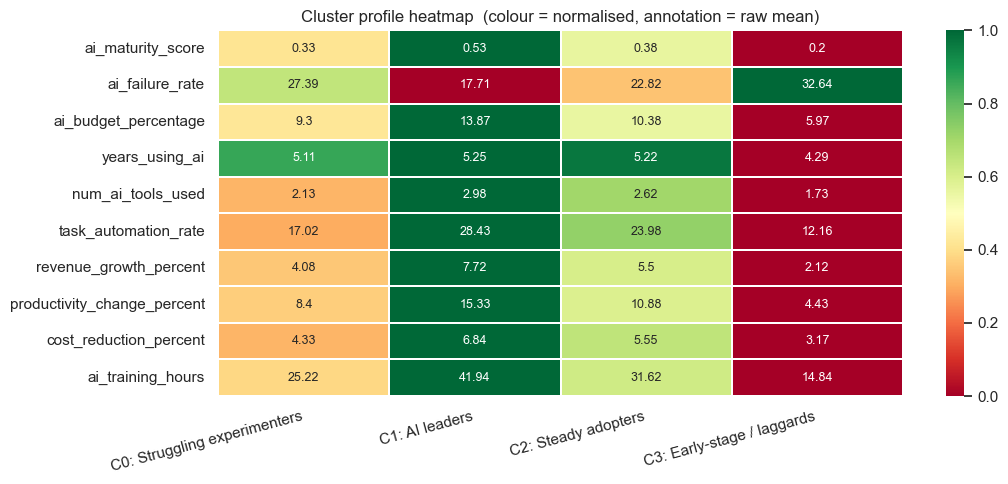

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
heat_data = profile[PROFILE_COLS].T
heat_data.columns = [f"C{c}: {cluster_names[c]}" for c in range(K)]
heat_norm = (
    heat_data
    .subtract(heat_data.min(axis=1), axis=0)
    .divide((heat_data.max(axis=1) - heat_data.min(axis=1) + 1e-9), axis=0)
)
sns.heatmap(
    heat_norm, annot=heat_data.round(2), fmt="g", cmap="RdYlGn",
    linewidths=0.3, ax=ax, annot_kws={"size": 9},
)
ax.set_title("Cluster profile heatmap  (colour = normalised, annotation = raw mean)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout()
plt.show()